# Policy Ranking Agreement (Q3)

Reads compact provenance from `outputs/in_distribution/policy_ranking_agreement/`.

**Question**: Does a user simulator rank recommender policies in the same order as real held-out data?

**Protocol**: Each policy generates a top-k recommendation list per evaluation user. A scorer assigns a simulated score to every recommended item. Mean simulated score becomes the policy's simulated utility; mean real target (held-out hit rate) becomes the real utility. Kendall's τ and Spearman's ρ measure agreement between the simulated and real policy rankings.

**Main metric**: `test.kendall_tau`. Spearman's ρ is reported alongside as a secondary measure. Both are `None` when fewer than 3 policies are evaluated (undefined for K < 3 — see `warning` field).

**Sections**:
1. Setup and artifact collection
2. Per-run results table
3. Policy utilities (simulated vs. real, per run)
4. Seed-averaged rank correlations
5. Verifications

In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path
from typing import Any

import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", None)


def find_repo_root(start: Path | None = None) -> Path:
    path = (start or Path.cwd()).resolve()
    for candidate in [path, *path.parents]:
        if (candidate / "pyproject.toml").exists() and candidate.name == "beyond-click-sim":
            return candidate
    raise RuntimeError("Could not find beyond-click-sim repo root")


REPO_ROOT = find_repo_root()
RESULTS_ROOT = REPO_ROOT / "outputs" / "in_distribution" / "policy_ranking_agreement"

METHODS = {
    "popularity_scorer": "Popularity scorer",
}
DATASET_LABELS = {"ml-1m": "ML-1M", "steam": "Steam"}

TASK_RE = re.compile(
    r"^(?P<dataset>ml-1m|steam)_policy_ranking"
    r"(?:_eval_users(?P<eval_users>\d+))?"
    r"_seed(?P<seed>\d+)$"
)
RUN_TS_RE = re.compile(r"^(?P<timestamp>\d{8}T\d{6}Z)_")

print(f"REPO_ROOT: {REPO_ROOT}")
print(f"RESULTS_ROOT: {RESULTS_ROOT}")
print(f"Results directory exists: {RESULTS_ROOT.exists()}")
if RESULTS_ROOT.exists():
    run_dirs = [p for p in RESULTS_ROOT.iterdir() if p.is_dir()]
    print(f"Run directories found: {len(run_dirs)}")

REPO_ROOT: /Users/a.ashabokov/Documents/projects/beyond-click-sim/beyond-click-sim
RESULTS_ROOT: /Users/a.ashabokov/Documents/projects/beyond-click-sim/beyond-click-sim/outputs/in_distribution/policy_ranking_agreement
Results directory exists: True
Run directories found: 8


In [2]:
def read_json(path: Path) -> dict[str, Any]:
    return json.loads(path.read_text(encoding="utf-8"))


def as_dict(value: Any) -> dict[str, Any]:
    return value if isinstance(value, dict) else {}


def as_list(value: Any) -> list:
    return value if isinstance(value, list) else []


def timestamp_from_run_dir(run_dir: Path) -> str:
    match = RUN_TS_RE.match(run_dir.name)
    return "" if match is None else match.group("timestamp")


def parse_task_name(task: str) -> dict[str, Any]:
    match = TASK_RE.match(task)
    if match is None:
        return {"dataset": "unknown", "eval_users": None, "seed": -1}
    return {
        "dataset": match.group("dataset"),
        "eval_users": int(match.group("eval_users")) if match.group("eval_users") else None,
        "seed": int(match.group("seed")),
    }


def float_or_none(value: Any) -> float | None:
    return None if value is None else float(value)

In [3]:
def collect_runs() -> pd.DataFrame:
    """Scan RESULTS_ROOT for policy ranking agreement artifacts.

    Returns one row per (task, method, run directory). If multiple runs exist
    for the same (task, method), all are kept — use `latest_runs` to keep only
    the most recent.
    """
    if not RESULTS_ROOT.exists():
        print(f"WARNING: {RESULTS_ROOT} does not exist. No runs found.")
        print("Run the runner first:")
        print("  uv run python -m runners.in_distribution.policy_ranking_agreement.run")
        return pd.DataFrame()

    rows: list[dict[str, Any]] = []
    for metrics_path in sorted(RESULTS_ROOT.glob("*/metrics.json")):
        run_dir = metrics_path.parent
        manifest_path = run_dir / "manifest.json"
        predictions_path = run_dir / "predictions.parquet"

        metrics = read_json(metrics_path)
        if metrics.get("protocol") != "policy_ranking":
            continue

        method = str(metrics.get("method", ""))
        task = str(metrics.get("task", ""))
        task_info = parse_task_name(task)
        test_block = as_dict(metrics.get("test"))
        manifest = read_json(manifest_path) if manifest_path.exists() else {}
        task_manifest = as_dict(as_dict(manifest.get("task")).get("manifest"))
        policies_manifest = as_list(task_manifest.get("policies"))
        policy_names_manifest = [p.get("name") for p in policies_manifest]

        rows.append({
            "timestamp": timestamp_from_run_dir(run_dir),
            "run": run_dir.name,
            "task": task,
            "method": method,
            "method_label": METHODS.get(method, method),
            "dataset": task_info["dataset"],
            "eval_users": task_info["eval_users"],
            "seed": task_info["seed"],
            "n_policies": test_block.get("n_policies"),
            "kendall_tau": float_or_none(test_block.get("kendall_tau")),
            "kendall_tau_pvalue": float_or_none(test_block.get("kendall_tau_pvalue")),
            "spearman_rho": float_or_none(test_block.get("spearman_rho")),
            "spearman_rho_pvalue": float_or_none(test_block.get("spearman_rho_pvalue")),
            "simulated_rank": as_list(test_block.get("simulated_rank")),
            "real_rank": as_list(test_block.get("real_rank")),
            "simulated_utilities": as_dict(test_block.get("simulated_utilities")),
            "real_utilities": as_dict(test_block.get("real_utilities")),
            "warning": test_block.get("warning"),
            "utility_aggregation": metrics.get("utility_aggregation"),
            "policy_names_manifest": policy_names_manifest,
            "has_predictions": predictions_path.exists(),
            "train_rows": as_dict(task_manifest.get("rows")).get("train"),
            "test_rows": as_dict(task_manifest.get("rows")).get("test"),
            "train_users": as_dict(task_manifest.get("users")).get("train"),
            "test_users": as_dict(task_manifest.get("users")).get("test"),
        })

    if not rows:
        print("No policy ranking agreement metrics.json files found in RESULTS_ROOT.")
        print("Run the runner first:")
        print("  uv run python -m runners.in_distribution.policy_ranking_agreement.run")
        return pd.DataFrame()

    return (
        pd.DataFrame(rows)
        .sort_values(["dataset", "method", "seed", "timestamp"])
        .reset_index(drop=True)
    )


all_runs = collect_runs()
if all_runs.empty:
    print("No runs found — remaining cells will produce empty output.")
else:
    print(f"Total runs collected: {len(all_runs)}")
    display(all_runs[["dataset", "method", "seed", "timestamp", "run"]].head(20))

Total runs collected: 6


,dataset,method,seed,timestamp,run
0,ml-1m,llm_yes_no_vllm_qwen36_27b_full,0,20260713T164742Z,20260713T164742Z_ml-1m_policy_ranking_eval_users1000_seed0_llm_yes_no_vllm_qwen36_27b_full
1,ml-1m,llm_yes_no_vllm_qwen36_27b_full,1,20260713T170347Z,20260713T170347Z_ml-1m_policy_ranking_eval_users1000_seed1_llm_yes_no_vllm_qwen36_27b_full
2,ml-1m,llm_yes_no_vllm_qwen36_27b_full,2,20260713T172826Z,20260713T172826Z_ml-1m_policy_ranking_eval_users1000_seed2_llm_yes_no_vllm_qwen36_27b_full
3,steam,llm_yes_no_vllm_qwen36_27b_full,0,20260713T181952Z,20260713T181952Z_steam_policy_ranking_eval_users1000_seed0_llm_yes_no_vllm_qwen36_27b_full
4,steam,llm_yes_no_vllm_qwen36_27b_full,1,20260713T200417Z,20260713T200417Z_steam_policy_ranking_eval_users1000_seed1_llm_yes_no_vllm_qwen36_27b_full
5,steam,llm_yes_no_vllm_qwen36_27b_full,2,20260713T214423Z,20260713T214423Z_steam_policy_ranking_eval_users1000_seed2_llm_yes_no_vllm_qwen36_27b_full


In [4]:
# Keep the most recent run per (task, method) — dedup by latest timestamp.
if not all_runs.empty:
    latest_runs = (
        all_runs
        .sort_values(["task", "method", "timestamp", "run"])
        .groupby(["task", "method"], as_index=False, dropna=False)
        .tail(1)
        .sort_values(["dataset", "method", "seed"])
        .reset_index(drop=True)
    )
else:
    latest_runs = all_runs.copy()

## Per-Run Results Table

One row per (task, method). `kendall_tau` and `spearman_rho` are `None` when fewer than 3 policies are evaluated — check the `warning` column. `simulated_rank` and `real_rank` show the full policy ordering (from best to worst) under each perspective.

In [26]:
if not latest_runs.empty:
    display_cols = [
        "dataset", "method_label", "seed",
        "n_policies", "kendall_tau", "kendall_tau_pvalue",
        "spearman_rho", "spearman_rho_pvalue",
        "simulated_rank", "real_rank",
        "simulated_utilities", "real_utilities",
        "warning", "train_rows", "test_rows", "test_users", "run",
    ]
    display_cols = [c for c in display_cols if c in latest_runs.columns]
    # display_cols = latest_runs.columns

    display(
        latest_runs[display_cols].style
        .format({
            "kendall_tau": "{:.4f}",
            "kendall_tau_pvalue": "{:.4f}",
            "spearman_rho": "{:.4f}",
            "spearman_rho_pvalue": "{:.4f}",
        }, na_rep="--")
        .hide(axis="index")
    )

dataset,method_label,seed,n_policies,kendall_tau,kendall_tau_pvalue,spearman_rho,spearman_rho_pvalue,simulated_rank,real_rank,simulated_utilities,real_utilities,warning,train_rows,test_rows,test_users,run
ml-1m,llm_yes_no_vllm_qwen36_27b_full,0,6,0.8667,0.0167,0.9429,0.0048,"['ItemKNNPolicy', 'ALSPolicy', 'BPRPolicy', 'PopularityPolicy', 'LightGCNPolicy', 'RandomPolicy']","['ALSPolicy', 'ItemKNNPolicy', 'BPRPolicy', 'PopularityPolicy', 'LightGCNPolicy', 'RandomPolicy']","{'ALSPolicy': 0.8169, 'BPRPolicy': 0.7588, 'ItemKNNPolicy': 0.856, 'LightGCNPolicy': 0.6819, 'PopularityPolicy': 0.6897, 'RandomPolicy': 0.3887}","{'ALSPolicy': 0.3605, 'BPRPolicy': 0.2284, 'ItemKNNPolicy': 0.3106, 'LightGCNPolicy': 0.1912, 'PopularityPolicy': 0.1928, 'RandomPolicy': 0.0088}",--,797758,60000,1000,20260713T164742Z_ml-1m_policy_ranking_eval_users1000_seed0_llm_yes_no_vllm_qwen36_27b_full
ml-1m,llm_yes_no_vllm_qwen36_27b_full,1,6,0.8667,0.0167,0.9429,0.0048,"['ItemKNNPolicy', 'ALSPolicy', 'BPRPolicy', 'PopularityPolicy', 'LightGCNPolicy', 'RandomPolicy']","['ALSPolicy', 'ItemKNNPolicy', 'BPRPolicy', 'PopularityPolicy', 'LightGCNPolicy', 'RandomPolicy']","{'ALSPolicy': 0.8182, 'BPRPolicy': 0.7539, 'ItemKNNPolicy': 0.8488, 'LightGCNPolicy': 0.6693, 'PopularityPolicy': 0.6859, 'RandomPolicy': 0.395}","{'ALSPolicy': 0.352, 'BPRPolicy': 0.2195, 'ItemKNNPolicy': 0.3058, 'LightGCNPolicy': 0.1814, 'PopularityPolicy': 0.1823, 'RandomPolicy': 0.0084}",--,797758,60000,1000,20260713T170347Z_ml-1m_policy_ranking_eval_users1000_seed1_llm_yes_no_vllm_qwen36_27b_full
ml-1m,llm_yes_no_vllm_qwen36_27b_full,2,6,0.8667,0.0167,0.9429,0.0048,"['ItemKNNPolicy', 'ALSPolicy', 'BPRPolicy', 'PopularityPolicy', 'LightGCNPolicy', 'RandomPolicy']","['ALSPolicy', 'ItemKNNPolicy', 'BPRPolicy', 'PopularityPolicy', 'LightGCNPolicy', 'RandomPolicy']","{'ALSPolicy': 0.8164, 'BPRPolicy': 0.7686, 'ItemKNNPolicy': 0.8507, 'LightGCNPolicy': 0.6742, 'PopularityPolicy': 0.6892, 'RandomPolicy': 0.3785}","{'ALSPolicy': 0.3473, 'BPRPolicy': 0.2189, 'ItemKNNPolicy': 0.2976, 'LightGCNPolicy': 0.1697, 'PopularityPolicy': 0.1726, 'RandomPolicy': 0.0099}",--,797758,60000,1000,20260713T172826Z_ml-1m_policy_ranking_eval_users1000_seed2_llm_yes_no_vllm_qwen36_27b_full
steam,llm_yes_no_vllm_qwen36_27b_full,0,6,0.2000,0.7194,0.3143,0.5441,"['ItemKNNPolicy', 'LightGCNPolicy', 'PopularityPolicy', 'ALSPolicy', 'BPRPolicy', 'RandomPolicy']","['ALSPolicy', 'ItemKNNPolicy', 'BPRPolicy', 'PopularityPolicy', 'LightGCNPolicy', 'RandomPolicy']","{'ALSPolicy': 0.6581, 'BPRPolicy': 0.5747, 'ItemKNNPolicy': 0.7035, 'LightGCNPolicy': 0.6901, 'PopularityPolicy': 0.6811, 'RandomPolicy': 0.1577}","{'ALSPolicy': 0.3134, 'BPRPolicy': 0.1994, 'ItemKNNPolicy': 0.2711, 'LightGCNPolicy': 0.1779, 'PopularityPolicy': 0.1816, 'RandomPolicy': 0.0014}",--,4007671,60000,1000,20260713T181952Z_steam_policy_ranking_eval_users1000_seed0_llm_yes_no_vllm_qwen36_27b_full
steam,llm_yes_no_vllm_qwen36_27b_full,1,6,0.2000,0.7194,0.3143,0.5441,"['ItemKNNPolicy', 'LightGCNPolicy', 'PopularityPolicy', 'ALSPolicy', 'BPRPolicy', 'RandomPolicy']","['ALSPolicy', 'ItemKNNPolicy', 'BPRPolicy', 'PopularityPolicy', 'LightGCNPolicy', 'RandomPolicy']","{'ALSPolicy': 0.6623, 'BPRPolicy': 0.5806, 'ItemKNNPolicy': 0.7051, 'LightGCNPolicy': 0.6775, 'PopularityPolicy': 0.6684, 'RandomPolicy': 0.171}","{'ALSPolicy': 0.3057, 'BPRPolicy': 0.2007, 'ItemKNNPolicy': 0.2689, 'LightGCNPolicy': 0.1777, 'PopularityPolicy': 0.1797, 'RandomPolicy': 0.0017}",--,4007671,60000,1000,20260713T200417Z_steam_policy_ranking_eval_users1000_seed1_llm_yes_no_vllm_qwen36_27b_full
steam,llm_yes_no_vllm_qwen36_27b_full,2,6,0.3333,0.4694,0.4857,0.3287,"['ItemKNNPolicy', 'LightGCNPolicy', 'ALSPolicy', 'PopularityPolicy', 'BPRPolicy', 'RandomPolicy']","['ALSPolicy', 'ItemKNNPolicy', 'BPRPolicy', 'PopularityPolicy', 'LightGCNPolicy', 'RandomPolicy']","{'ALSPolicy': 0.6692, 'BPRPolicy': 0.5937, 'ItemKNNPolicy': 0.7073, 'LightGCNPolicy': 0.6772, 'PopularityPolicy': 0.6673, 'RandomPolicy'

In [29]:
latest_runs["real_rank"][0]

['ALSPolicy',
 'ItemKNNPolicy',
 'BPRPolicy',
 'PopularityPolicy',
 'LightGCNPolicy',
 'RandomPolicy']

In [37]:
methods_df = pd.DataFrame({
    "policy": [
        'ALSPolicy',
        'ItemKNNPolicy',
        "BPRPolicy",
        "PopularityPolicy",
        "LightGCNPolicy",
        "RandomPolicy",
    ]
})

policy_metrics_cols = [
    "dataset", "method_label", "seed",
    "simulated_utilities", "real_utilities",
    # "simulated_rank", "real_rank",
]
scores_df = latest_runs[policy_metrics_cols].assign(key=1).merge(methods_df.assign(key=1), on="key").drop("key", axis=1)
scores_df["simulated_utility"] = scores_df.apply(lambda x: x["simulated_utilities"][x["policy"]], axis=1)
scores_df["real_utility"] = scores_df.apply(lambda x: x["real_utilities"][x["policy"]], axis=1)
scores_df = scores_df.drop(columns=["simulated_utilities", "real_utilities"])
scores_df["diff"] = scores_df["simulated_utility"] - scores_df["real_utility"]
scores_df

,dataset,method_label,seed,policy,simulated_utility,real_utility,diff
0,ml-1m,llm_yes_no_vllm_qwen36_27b_full,0,ALSPolicy,0.8169,0.3605,0.4564
1,ml-1m,llm_yes_no_vllm_qwen36_27b_full,0,ItemKNNPolicy,0.8560,0.3106,0.5454
2,ml-1m,llm_yes_no_vllm_qwen36_27b_full,0,BPRPolicy,0.7588,0.2284,0.5304
3,ml-1m,llm_yes_no_vllm_qwen36_27b_full,0,PopularityPolicy,0.6897,0.1928,0.4969
4,ml-1m,llm_yes_no_vllm_qwen36_27b_full,0,LightGCNPolicy,0.6819,0.1912,0.4907
5,ml-1m,llm_yes_no_vllm_qwen36_27b_full,0,RandomPolicy,0.3887,0.0088,0.3799
6,ml-1m,llm_yes_no_vllm_qwen36_27b_full,1,ALSPolicy,0.8182,0.3520,0.4662
7,ml-1m,llm_yes_no_vllm_qwen36_27b_full,1,ItemKNNPolicy,0.8488,0.3058,0.5430
8,ml-1m,llm_yes_no_vllm_qwen36_27b_full,1,BPRPolicy,0.7539,0.2195,0.5344
9,ml-1m,llm_yes_no_vllm_qwen36_27b_full,1,PopularityPolicy,0.6859,0.1823,0.5036


In [46]:
import plotly.express as px

ml1m_diff = scores_df.query("dataset == 'ml-1m'")["diff"]
fig = px.histogram(
    ml1m_diff,
    nbins=10,
    title="Distribution of Simulated - Real Utility Difference (ML-1M)",
    labels={"value": "Simulated - Real Utility Difference", "count": "Count"},
)
fig.update_layout(bargap=0.1)
fig.show()

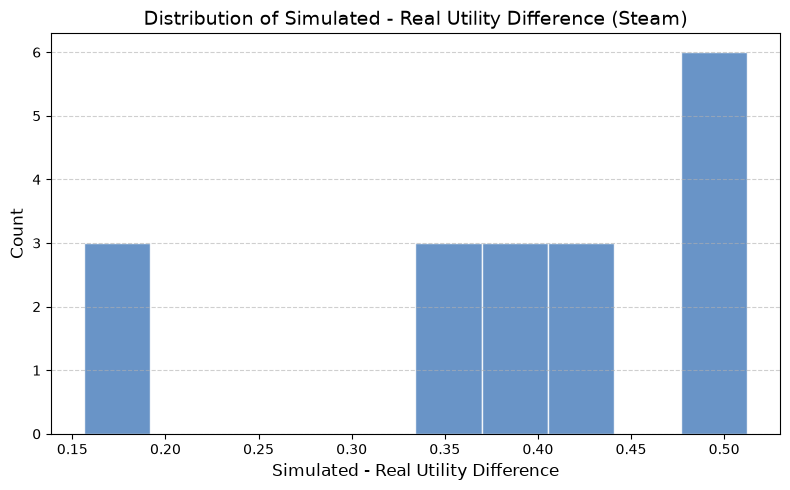

In [47]:
import matplotlib.pyplot as plt

steam_diff = scores_df.query("dataset == 'steam'")["diff"]
plt.figure(figsize=(8, 5))
n, bins, patches = plt.hist(
    steam_diff, 
    bins=10, 
    color="#4F81BD", 
    edgecolor="white", 
    alpha=0.85
)
plt.title("Distribution of Simulated - Real Utility Difference (Steam)", fontsize=14)
plt.xlabel("Simulated - Real Utility Difference", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [24]:
print(latest_runs[display_cols].to_markdown())

|    | dataset   | method_label                    |   seed |   n_policies |   kendall_tau |   kendall_tau_pvalue |   spearman_rho |   spearman_rho_pvalue | simulated_rank                                                                                    | real_rank                                                                                         | warning   |   train_rows |   test_rows |   test_users | run                                                                                        |
|---:|:----------|:--------------------------------|-------:|-------------:|--------------:|---------------------:|---------------:|----------------------:|:--------------------------------------------------------------------------------------------------|:--------------------------------------------------------------------------------------------------|:----------|-------------:|------------:|-------------:|:---------------------------------------------------------------------------------

In [48]:
"""
Four complementary views, each answering a different question:

  1. plot_correlation_summary  -> "Overall: does the scorer preserve rank,
                                    and is that reliable across datasets/methods?"
  2. plot_seed_dispersion      -> "How stable is that agreement across seeds?"
                                    (variance itself is a finding, not noise)
  3. plot_rank_bump            -> "Where exactly does the scorer's ranking
                                    diverge from ground truth, policy by policy?"
  4. plot_pairwise_concordance -> "Which specific pairs of policies does the
                                    scorer confuse, aggregated over seeds?"

All functions take the raw dataframe (as in your example) and parse
simulated_rank / real_rank whether they're already lists or stringified
lists (e.g. read back from a CSV).
"""
import ast
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# --------------------------------------------------------------------------
# prep
# --------------------------------------------------------------------------
def _parse_rank(x):
    if isinstance(x, str):
        return ast.literal_eval(x)
    return list(x)


def prepare(df):
    df = df.copy()
    df["simulated_rank"] = df["simulated_rank"].apply(_parse_rank)
    df["real_rank"] = df["real_rank"].apply(_parse_rank)
    return df


# --------------------------------------------------------------------------
# 1. correlation summary: mean +/- spread across seeds, per (dataset, method)
# --------------------------------------------------------------------------
def plot_correlation_summary(
    df,
    group_cols=("dataset", "method_label"),
    metrics=("kendall_tau", "spearman_rho"),
    pvalue_suffix="_pvalue",
    alpha=0.05,
    figsize=None,
):
    groups = list(df.groupby(list(group_cols)))
    labels = [
        " | ".join(str(x) for x in (g if isinstance(g, tuple) else (g,)))
        for g, _ in groups
    ]
    y = np.arange(len(groups))

    figsize = figsize or (4.5 * len(metrics), 0.6 * len(groups) + 1.5)
    fig, axes = plt.subplots(1, len(metrics), figsize=figsize, sharey=True)
    if len(metrics) == 1:
        axes = [axes]

    for ax, metric in zip(axes, metrics):
        pcol = metric + pvalue_suffix
        means, stds, sig = [], [], []
        for _, gdf in groups:
            vals = gdf[metric].to_numpy(dtype=float)
            means.append(vals.mean())
            stds.append(vals.std() if len(vals) > 1 else 0.0)
            sig.append((gdf[pcol] < alpha).all() if pcol in gdf else True)

        means, stds, sig = np.array(means), np.array(stds), np.array(sig)

        ax.axvline(0, color="0.8", lw=1, zorder=0)
        ax.errorbar(
            means, y, xerr=stds, fmt="none", ecolor="0.5", elinewidth=1.2,
            capsize=3, zorder=1,
        )
        ax.scatter(
            means[sig], y[sig], s=70, facecolor="#2563eb", edgecolor="#1e3a8a",
            zorder=2, label="sig. all seeds (p<%.2f)" % alpha,
        )
        ax.scatter(
            means[~sig], y[~sig], s=70, facecolor="white", edgecolor="#1e3a8a",
            zorder=2, label="not sig. every seed",
        )
        ax.set_xlim(-1.05, 1.05)
        ax.set_title(metric.replace("_", " "))
        ax.set_xlabel("correlation with ground-truth rank")
        ax.grid(axis="x", ls=":", alpha=0.5)

    axes[0].set_yticks(y)
    axes[0].set_yticklabels(labels)
    axes[0].invert_yaxis()
    handles, labs = axes[-1].get_legend_handles_labels()
    fig.legend(handles, labs, loc="lower center", ncol=2, frameon=False,
               bbox_to_anchor=(0.5, -0.02))
    fig.suptitle("LLM scorer vs. ground truth: rank-correlation summary\n"
                 "(point = mean over seeds, whiskers = std over seeds)", y=1.02)
    fig.tight_layout()
    return fig


# --------------------------------------------------------------------------
# 2. seed-level dispersion (is agreement stable, or seed-dependent?)
# --------------------------------------------------------------------------
def plot_seed_dispersion(df, group_cols=("dataset", "method_label"),
                          metric="kendall_tau", figsize=None):
    groups = list(df.groupby(list(group_cols)))
    labels = [
        " | ".join(str(x) for x in (g if isinstance(g, tuple) else (g,)))
        for g, _ in groups
    ]
    figsize = figsize or (6, 0.7 * len(groups) + 1.5)
    fig, ax = plt.subplots(figsize=figsize)

    rng = np.random.default_rng(0)
    for i, (_, gdf) in enumerate(groups):
        vals = gdf[metric].to_numpy(dtype=float)
        jitter = rng.uniform(-0.12, 0.12, size=len(vals))
        ax.scatter(vals, np.full_like(vals, i, dtype=float) + jitter,
                   s=45, color="#2563eb", alpha=0.85, zorder=2)
        ax.scatter(vals.mean(), i, s=140, marker="|", color="black", zorder=3)

    ax.axvline(0, color="0.8", lw=1, zorder=0)
    ax.set_yticks(range(len(groups)))
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_xlim(-1.05, 1.05)
    ax.set_xlabel(metric.replace("_", " "))
    ax.grid(axis="x", ls=":", alpha=0.5)
    ax.set_title(f"Seed-to-seed stability of {metric.replace('_', ' ')}\n"
                 "(dots = individual seeds, | = mean)")
    fig.tight_layout()
    return fig


# --------------------------------------------------------------------------
# 3. bump / slope chart: real rank vs. simulated rank, policy by policy
# --------------------------------------------------------------------------
def plot_rank_bump(df, dataset, method_label=None, figsize=(6, 5)):
    sub = df[df["dataset"] == dataset]
    if method_label is not None:
        sub = sub[sub["method_label"] == method_label]
    if sub.empty:
        raise ValueError("No rows match that dataset/method_label.")

    real_order = sub.iloc[0]["real_rank"]
    policies = real_order
    cmap = plt.get_cmap("tab10")
    colors = {p: cmap(i % 10) for i, p in enumerate(policies)}

    fig, ax = plt.subplots(figsize=figsize)
    n_seeds = len(sub)

    for _, row in sub.iterrows():
        sim_order = row["simulated_rank"]
        for p in policies:
            y_real = real_order.index(p)
            y_sim = sim_order.index(p)
            ax.plot([0, 1], [y_real, y_sim], color=colors[p],
                    alpha=max(0.25, 1.0 / n_seeds), lw=2.2, zorder=1)

    for p in policies:
        y_real = real_order.index(p)
        ax.scatter(0, y_real, s=60, color=colors[p], zorder=2)
        ax.text(-0.04, y_real, p, ha="right", va="center", fontsize=9)

    ax.set_xlim(-0.5, 1.3)
    ax.set_ylim(len(policies) - 0.5, -0.5)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["ground truth", "LLM simulated\n(each line = one seed)"])
    ax.set_yticks([])
    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)
    title = f"{dataset}" + (f" | {method_label}" if method_label else "")
    ax.set_title(f"Rank divergence: {title}")
    fig.tight_layout()
    return fig


# --------------------------------------------------------------------------
# 4. pairwise concordance heatmap (decomposes Kendall's tau by policy pair)
# --------------------------------------------------------------------------
def plot_pairwise_concordance(df, dataset, method_label=None, figsize=(5.5, 5)):
    sub = df[df["dataset"] == dataset]
    if method_label is not None:
        sub = sub[sub["method_label"] == method_label]
    if sub.empty:
        raise ValueError("No rows match that dataset/method_label.")

    real_order = sub.iloc[0]["real_rank"]
    policies = real_order  # order rows/cols by ground-truth rank
    n = len(policies)
    mat = np.full((n, n), np.nan)

    for i, j in combinations(range(n), 2):
        pi, pj = policies[i], policies[j]
        agree = []
        for _, row in sub.iterrows():
            sim = row["simulated_rank"]
            real_sign = np.sign(real_order.index(pi) - real_order.index(pj))
            sim_sign = np.sign(sim.index(pi) - sim.index(pj))
            agree.append(real_sign == sim_sign)
        rate = np.mean(agree)
        mat[i, j] = rate
        mat[j, i] = rate

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(mat, cmap="RdYlGn", vmin=0, vmax=1)
    ax.set_xticks(range(n)); ax.set_xticklabels(policies, rotation=45, ha="right")
    ax.set_yticks(range(n)); ax.set_yticklabels(policies)
    for i in range(n):
        for j in range(n):
            if i != j:
                ax.text(j, i, f"{mat[i, j]:.2f}", ha="center", va="center",
                        fontsize=8, color="black")
    fig.colorbar(im, ax=ax, label="fraction of seeds with concordant pair order")
    title = f"{dataset}" + (f" | {method_label}" if method_label else "")
    ax.set_title(f"Pairwise rank concordance: {title}\n"
                 "(rows/cols ordered by ground-truth rank)")
    fig.tight_layout()
    return fig

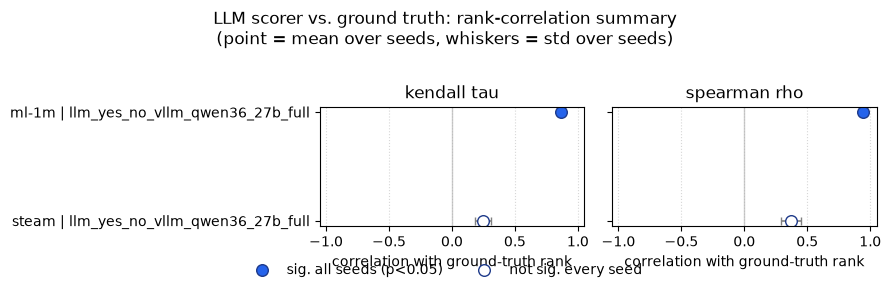

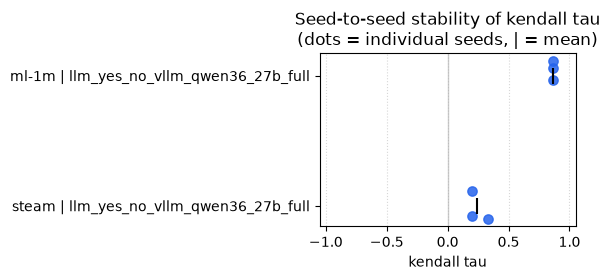

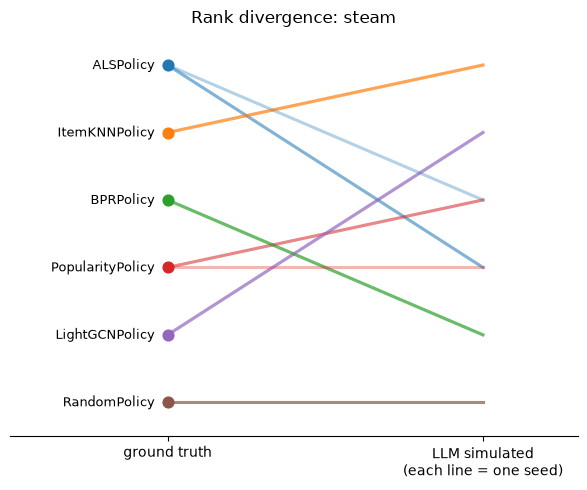

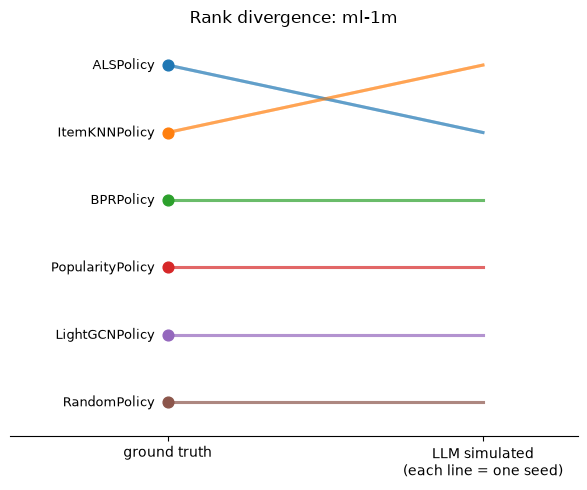

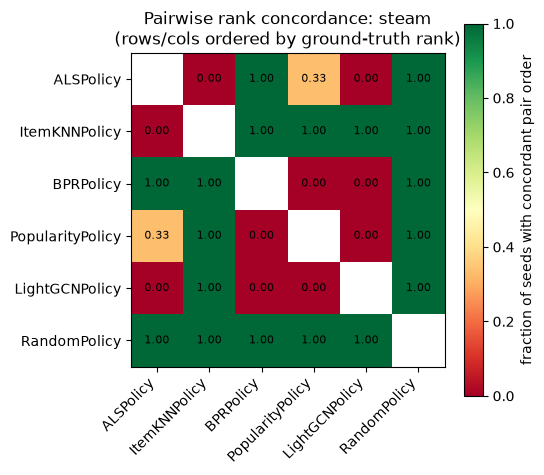

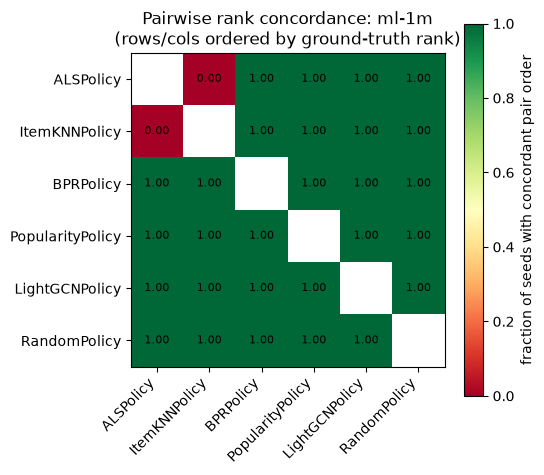

done


In [51]:
df = latest_runs[display_cols]
fig1 = plot_correlation_summary(df)
# fig1.savefig("/mnt/user-data/outputs/1_correlation_summary.png", dpi=160, bbox_inches="tight")
plt.show()

fig2 = plot_seed_dispersion(df, metric="kendall_tau")
# fig2.savefig("/mnt/user-data/outputs/2_seed_dispersion.png", dpi=160, bbox_inches="tight")
plt.show()

fig3 = plot_rank_bump(df, dataset="steam")
# fig3.savefig("/mnt/user-data/outputs/3_rank_bump_steam.png", dpi=160, bbox_inches="tight")
plt.show()

fig3 = plot_rank_bump(df, dataset="ml-1m")
# fig3.savefig("/mnt/user-data/outputs/3_rank_bump_steam.png", dpi=160, bbox_inches="tight")
plt.show()

fig4 = plot_pairwise_concordance(df, dataset="steam")
# fig4.savefig("/mnt/user-data/outputs/4_pairwise_concordance_steam.png", dpi=160, bbox_inches="tight")
plt.show()

fig4 = plot_pairwise_concordance(df, dataset="ml-1m")
# fig4.savefig("/mnt/user-data/outputs/4_pairwise_concordance_steam.png", dpi=160, bbox_inches="tight")
plt.show()

print("done")

## Policy Utilities (Simulated vs. Real)

For each run, show the per-policy mean simulated score (what the scorer thinks of those recommendations) and the per-policy mean real target (actual held-out hit rate). The agreement between the orderings of these two columns is what Kendall's τ and Spearman's ρ capture.

In [6]:
def expand_utilities(runs: pd.DataFrame) -> pd.DataFrame:
    """Expand simulated_utilities and real_utilities dicts into long-format rows."""
    rows = []
    for _, run in runs.iterrows():
        sim_util = run["simulated_utilities"]
        real_util = run["real_utilities"]
        all_policies = sorted(set(list(sim_util.keys()) + list(real_util.keys())))
        for policy in all_policies:
            rows.append({
                "dataset": run["dataset"],
                "method_label": run["method_label"],
                "seed": run["seed"],
                "policy": policy,
                "simulated_utility": sim_util.get(policy),
                "real_utility": real_util.get(policy),
                "simulated_rank_position": (
                    run["simulated_rank"].index(policy) + 1
                    if policy in run["simulated_rank"] else None
                ),
                "real_rank_position": (
                    run["real_rank"].index(policy) + 1
                    if policy in run["real_rank"] else None
                ),
            })
    return pd.DataFrame(rows)


if not latest_runs.empty:
    utilities_df = expand_utilities(latest_runs)
    display(
        utilities_df.style
        .format({
            "simulated_utility": "{:.6f}",
            "real_utility": "{:.6f}",
        }, na_rep="--")
        .hide(axis="index")
    )

dataset,method_label,seed,policy,simulated_utility,real_utility,simulated_rank_position,real_rank_position
ml-1m,llm_yes_no_vllm_qwen36_27b_full,0,ALSPolicy,0.816900,0.360500,2,1
ml-1m,llm_yes_no_vllm_qwen36_27b_full,0,BPRPolicy,0.758800,0.228400,3,3
ml-1m,llm_yes_no_vllm_qwen36_27b_full,0,ItemKNNPolicy,0.856000,0.310600,1,2
ml-1m,llm_yes_no_vllm_qwen36_27b_full,0,LightGCNPolicy,0.681900,0.191200,5,5
ml-1m,llm_yes_no_vllm_qwen36_27b_full,0,PopularityPolicy,0.689700,0.192800,4,4
ml-1m,llm_yes_no_vllm_qwen36_27b_full,0,RandomPolicy,0.388700,0.008800,6,6
ml-1m,llm_yes_no_vllm_qwen36_27b_full,1,ALSPolicy,0.818200,0.352000,2,1
ml-1m,llm_yes_no_vllm_qwen36_27b_full,1,BPRPolicy,0.753900,0.219500,3,3
ml-1m,llm_yes_no_vllm_qwen36_27b_full,1,ItemKNNPolicy,0.848800,0.305800,1,2
ml-1m,llm_yes_no_vllm_qwen36_27b_full,1,LightGCNPolicy,0.669300,0.181400,5,5


## Seed-Averaged Rank Correlations

Mean and std of Kendall's τ and Spearman's ρ across seeds, grouped by (dataset, method). Only includes seeds where both metrics are non-null (i.e. K ≥ 3 policies). Seeds where K < 3 are counted but excluded from the average.

In [7]:
if not latest_runs.empty:
    valid = latest_runs.dropna(subset=["kendall_tau", "spearman_rho"])
    excluded = len(latest_runs) - len(valid)
    if excluded > 0:
        print(f"NOTE: {excluded} run(s) excluded from seed average (K < 3 policies, tau/rho undefined).")

    if valid.empty:
        print("No runs with K ≥ 3 policies to average.")
    else:
        summary = (
            valid
            .groupby(["dataset", "method_label"], dropna=False)
            .agg(
                n_seeds=("seed", "nunique"),
                seeds=("seed", lambda s: tuple(sorted(int(v) for v in s))),
                kendall_tau_mean=("kendall_tau", "mean"),
                kendall_tau_std=("kendall_tau", "std"),
                spearman_rho_mean=("spearman_rho", "mean"),
                spearman_rho_std=("spearman_rho", "std"),
                kendall_tau_pvalue_mean=("kendall_tau_pvalue", "mean"),
                spearman_rho_pvalue_mean=("spearman_rho_pvalue", "mean"),
            )
            .reset_index()
        )
        display(
            summary.style
            .format({
                "kendall_tau_mean": "{:.4f}",
                "kendall_tau_std": "{:.4f}",
                "spearman_rho_mean": "{:.4f}",
                "spearman_rho_std": "{:.4f}",
                "kendall_tau_pvalue_mean": "{:.4f}",
                "spearman_rho_pvalue_mean": "{:.4f}",
            }, na_rep="--")
            .hide(axis="index")
        )

dataset,method_label,n_seeds,seeds,kendall_tau_mean,kendall_tau_std,spearman_rho_mean,spearman_rho_std,kendall_tau_pvalue_mean,spearman_rho_pvalue_mean
ml-1m,llm_yes_no_vllm_qwen36_27b_full,3,"(0, 1, 2)",0.8667,0.0000,0.9429,0.0000,0.0167,0.0048
steam,llm_yes_no_vllm_qwen36_27b_full,3,"(0, 1, 2)",0.2444,0.0770,0.3714,0.0990,0.6361,0.4723


## Verifications

Structural integrity checks on the collected artifacts. Each check should produce no failures on well-formed runs.

In [8]:
def check_policy_name_consistency(runs: pd.DataFrame) -> None:
    """Verify that policy names in metrics match those declared in the manifest."""
    failures = []
    for _, run in runs.iterrows():
        manifest_names = set(run["policy_names_manifest"])
        metrics_names = set(run["simulated_utilities"].keys())
        if manifest_names and metrics_names and manifest_names != metrics_names:
            failures.append({
                "run": run["run"],
                "manifest_policies": sorted(manifest_names),
                "metrics_policies": sorted(metrics_names),
            })
    if failures:
        print("FAIL: Policy name mismatch between manifest and metrics:")
        for f in failures:
            print(f"  run={f['run']}")
            print(f"    manifest: {f['manifest_policies']}")
            print(f"    metrics:  {f['metrics_policies']}")
    else:
        print(f"OK: All {len(runs)} runs have consistent policy names in manifest and metrics.")


if not latest_runs.empty:
    check_policy_name_consistency(latest_runs)

OK: All 6 runs have consistent policy names in manifest and metrics.


In [9]:
def check_rank_order_consistent_with_utilities(runs: pd.DataFrame) -> None:
    """Verify that simulated_rank is the descending sort of simulated_utilities,
    and real_rank is the descending sort of real_utilities.
    """
    failures = []
    for _, run in runs.iterrows():
        sim_util = run["simulated_utilities"]
        real_util = run["real_utilities"]
        sim_rank = run["simulated_rank"]
        real_rank = run["real_rank"]
        if not sim_util or not real_util:
            continue

        expected_sim_rank = sorted(sim_util, key=sim_util.__getitem__, reverse=True)
        expected_real_rank = sorted(real_util, key=real_util.__getitem__, reverse=True)

        if sim_rank != expected_sim_rank:
            failures.append({"run": run["run"], "kind": "simulated", "got": sim_rank, "expected": expected_sim_rank})
        if real_rank != expected_real_rank:
            failures.append({"run": run["run"], "kind": "real", "got": real_rank, "expected": expected_real_rank})

    if failures:
        print("FAIL: Rank order inconsistent with utilities:")
        for f in failures:
            print(f"  run={f['run']} kind={f['kind']}")
            print(f"    got:      {f['got']}")
            print(f"    expected: {f['expected']}")
    else:
        print(f"OK: All rank orders are consistent with utility values in all {len(runs)} runs.")


if not latest_runs.empty:
    check_rank_order_consistent_with_utilities(latest_runs)

OK: All rank orders are consistent with utility values in all 6 runs.


In [10]:
def check_predictions_parquet(runs: pd.DataFrame, results_root: Path) -> None:
    """Verify that predictions.parquet has expected columns and no 'prediction' column.

    Q3 is not a classification task — 'prediction' has no meaning here.
    Required columns: split, user_id, item_id, target, score, policy, rank.
    """
    required_cols = {"split", "user_id", "item_id", "target", "score", "policy", "rank"}
    failures = []

    for _, run in runs.iterrows():
        preds_path = results_root / run["run"] / "predictions.parquet"
        if not preds_path.exists():
            failures.append({"run": run["run"], "issue": "predictions.parquet missing"})
            continue
        preds = pd.read_parquet(preds_path)
        if "prediction" in preds.columns:
            failures.append({"run": run["run"], "issue": "has 'prediction' column (Q3 is not classification)"})
        missing = required_cols - set(preds.columns)
        if missing:
            failures.append({"run": run["run"], "issue": f"missing columns: {sorted(missing)}"})
        splits = set(preds["split"].unique())
        if splits != {"test"}:
            failures.append({"run": run["run"], "issue": f"unexpected split values: {splits} (expected only 'test')"})

    if failures:
        print("FAIL: predictions.parquet issues:")
        for f in failures:
            print(f"  run={f['run']}: {f['issue']}")
    else:
        n = sum(1 for _, r in runs.iterrows() if r["has_predictions"])
        print(f"OK: {n} predictions.parquet files have correct columns and split values.")


if not latest_runs.empty:
    check_predictions_parquet(latest_runs, RESULTS_ROOT)

OK: 6 predictions.parquet files have correct columns and split values.


In [11]:
def check_no_duplicate_seeds(runs: pd.DataFrame) -> None:
    """Verify that latest_runs has at most one run per (dataset, method, seed) — no silent duplicates."""
    dupes = (
        runs.groupby(["dataset", "method", "seed"], dropna=False)
        .size()
        .rename("count")
        .reset_index()
    )
    dupes = dupes[dupes["count"] > 1]
    if not dupes.empty:
        print("FAIL: Duplicate (dataset, method, seed) after deduplication:")
        display(dupes)
    else:
        print(f"OK: No duplicate (dataset, method, seed) entries in latest_runs ({len(runs)} runs).")


if not latest_runs.empty:
    check_no_duplicate_seeds(latest_runs)

OK: No duplicate (dataset, method, seed) entries in latest_runs (6 runs).


In [12]:
def check_utility_completeness(runs: pd.DataFrame) -> None:
    """Verify that simulated_utilities and real_utilities contain the same policy names."""
    failures = []
    for _, run in runs.iterrows():
        sim_keys = set(run["simulated_utilities"].keys())
        real_keys = set(run["real_utilities"].keys())
        if sim_keys != real_keys:
            failures.append({
                "run": run["run"],
                "sim_only": sorted(sim_keys - real_keys),
                "real_only": sorted(real_keys - sim_keys),
            })
    if failures:
        print("FAIL: Mismatched policy names between simulated and real utilities:")
        for f in failures:
            print(f"  run={f['run']}")
            if f["sim_only"]:
                print(f"    in simulated only: {f['sim_only']}")
            if f["real_only"]:
                print(f"    in real only: {f['real_only']}")
    else:
        print(f"OK: simulated_utilities and real_utilities cover the same policy names in all {len(runs)} runs.")


if not latest_runs.empty:
    check_utility_completeness(latest_runs)

OK: simulated_utilities and real_utilities cover the same policy names in all 6 runs.


In [13]:
def check_protocol_field(runs: pd.DataFrame, results_root: Path) -> None:
    """Verify that manifest.json has protocol='policy_ranking' in all runs."""
    failures = []
    for _, run in runs.iterrows():
        manifest_path = results_root / run["run"] / "manifest.json"
        if not manifest_path.exists():
            failures.append({"run": run["run"], "issue": "manifest.json missing"})
            continue
        manifest = read_json(manifest_path)
        protocol = manifest.get("protocol")
        if protocol != "policy_ranking":
            failures.append({"run": run["run"], "issue": f"protocol={protocol!r} (expected 'policy_ranking')"})
    if failures:
        print("FAIL:")
        for f in failures:
            print(f"  run={f['run']}: {f['issue']}")
    else:
        print(f"OK: All {len(runs)} manifests have protocol='policy_ranking'.")


if not latest_runs.empty:
    check_protocol_field(latest_runs, RESULTS_ROOT)

OK: All 6 manifests have protocol='policy_ranking'.


In [14]:
def check_k2_warning_present(runs: pd.DataFrame) -> None:
    """When K=2, tau/rho should be None and a warning should be set."""
    failures = []
    for _, run in runs.iterrows():
        if run["n_policies"] == 2:
            if run["kendall_tau"] is not None:
                failures.append({"run": run["run"], "issue": "kendall_tau is not None for K=2"})
            if not run["warning"]:
                failures.append({"run": run["run"], "issue": "warning is empty/None for K=2"})
    if failures:
        print("FAIL: K=2 invariant violated:")
        for f in failures:
            print(f"  run={f['run']}: {f['issue']}")
    else:
        k2_runs = (runs["n_policies"] == 2).sum() if not runs.empty else 0
        if k2_runs:
            print(f"PASS: {k2_runs} K=2 run(s) have tau=None and a warning set (as expected).")
        else:
            print("INFO: No K=2 runs found (all runs have K≥3, tau/rho are defined).")


if not latest_runs.empty:
    check_k2_warning_present(latest_runs)

INFO: No K=2 runs found (all runs have K≥3, tau/rho are defined).


## Coverage Summary

Which (dataset, method, seed) combinations have completed runs? Gaps indicate missing experiments.

In [15]:
if not latest_runs.empty:
    expected_datasets = ["ml-1m", "steam"]
    expected_seeds = list(range(5))
    expected_methods = list(METHODS.keys())

    coverage_rows = []
    for dataset in expected_datasets:
        for method in expected_methods:
            for seed in expected_seeds:
                match = latest_runs[
                    (latest_runs["dataset"] == dataset)
                    & (latest_runs["method"] == method)
                    & (latest_runs["seed"] == seed)
                ]
                if match.empty:
                    coverage_rows.append({"dataset": dataset, "method": METHODS.get(method, method), "seed": seed, "status": "MISSING", "run": ""})
                else:
                    row = match.iloc[0]
                    tau = row["kendall_tau"]
                    tau_str = f"{tau:.4f}" if tau is not None else "K<3"
                    coverage_rows.append({"dataset": dataset, "method": METHODS.get(method, method), "seed": seed, "status": f"OK (τ={tau_str})", "run": row["run"]})

    coverage_df = pd.DataFrame(coverage_rows)

    missing = (coverage_df["status"] == "MISSING").sum()
    if missing > 0:
        print(f"WARNING: {missing} (dataset, method, seed) combination(s) missing.")

    display(
        coverage_df.style
        .apply(lambda col: [
            "color: red; font-weight: bold" if v == "MISSING" else ""
            for v in col
        ], subset=["status"])
        .hide(axis="index")
    )

dataset,method,seed,status,run
ml-1m,Popularity scorer,0,MISSING,
ml-1m,Popularity scorer,1,MISSING,
ml-1m,Popularity scorer,2,MISSING,
ml-1m,Popularity scorer,3,MISSING,
ml-1m,Popularity scorer,4,MISSING,
steam,Popularity scorer,0,MISSING,
steam,Popularity scorer,1,MISSING,
steam,Popularity scorer,2,MISSING,
steam,Popularity scorer,3,MISSING,
steam,Popularity scorer,4,MISSING,
